# Predicting subsurface eddy tilt from surface signatures

This workflow tests AE and CE independently. It reserves a final set of unseen eddies before any model, target formulation, hyperparameter, or feature-set selection. Training gives each eddy equal total weight so long-lived eddies do not dominate.

Two target formulations compete during grouped training-only cross-validation:

1. direct eastward and northward tilt components;
2. `log1p(TiltDis)` and the circular directional offset from a polarity-specific PV reference.

The physical hypothesis is explicit but still tested rather than assumed: CE uses the PV-gradient bearing as its reference, while AE uses the opposite bearing (`PV_grad_theta + 180°`). The final test eddies are evaluated exactly once after all choices are fixed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_FOLDS = 5
REPEATED_SPLITS = 5

## 1. Load data and enforce a common vertical interval

Tilt is capped at the approximately 859 m model level. Only eddy-days with a vertical profile deeper than 850 m are retained, so every target represents the complete measured interval. Filtering occurs before the relatively expensive core-mean PV calculation.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)

max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max()
    .rename(columns={"Depth": "max_profile_depth"})
)
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

print(f"Rows reaching the full depth: {len(df_eddies):,}")
print(f"Eddies reaching the full depth: {df_eddies['Eddy'].nunique():,}")

Rows reaching the full depth: 88,199
Eddies reaching the full depth: 2,793


## 2. Engineer predictors and audit target coverage

The canonical predictors are:

```text
beta, h, Omega
prop_east_km_day, prop_north_km_day
ellipse_major_cos2, ellipse_major_sin2
PV_grad_mag, PV_grad_east, PV_grad_north
```

Only `beta` is used from the correlated latitude/Coriolis group; `lat` and `f` are excluded. `Omega` is used and `w` is excluded. Following the previous held-out importance results, `AR`, `Rc_tendency_km_day`, and `Omega_tendency_day` are removed. Ellipse orientation uses `sin(2θ)` and `cos(2θ)` because an ellipse axis is 180° periodic. Propagation components are daily differences within each eddy; missing first-day propagation is imputed inside each training fold.

In [3]:
display(ml.target_availability_summary(df_eddies))

model_df = ml.prepare_modelling_table(df_eddies)
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}

display(pd.DataFrame({
    cyc: {"rows": len(part), "eddies": part["Eddy"].nunique()}
    for cyc, part in polarity_data.items()
}).T)
display(pd.Series(ml.FEATURES, name="model_feature").to_frame())

,rows,valid_tilt_rows,valid_fraction,eddies,eddies_with_tilt
group,,,,,
All,88199,79390,0.900124,2793,2745
AE,42658,38935,0.912724,1319,1284
CE,45541,40455,0.888320,1474,1461


,rows,eddies
AE,38935,1284
CE,40455,1461


,model_feature
0,beta
1,h
2,prop_east_km_day
3,prop_north_km_day
4,ellipse_major_cos2
5,ellipse_major_sin2
6,Omega
7,PV_grad_mag
8,PV_grad_east
9,PV_grad_north


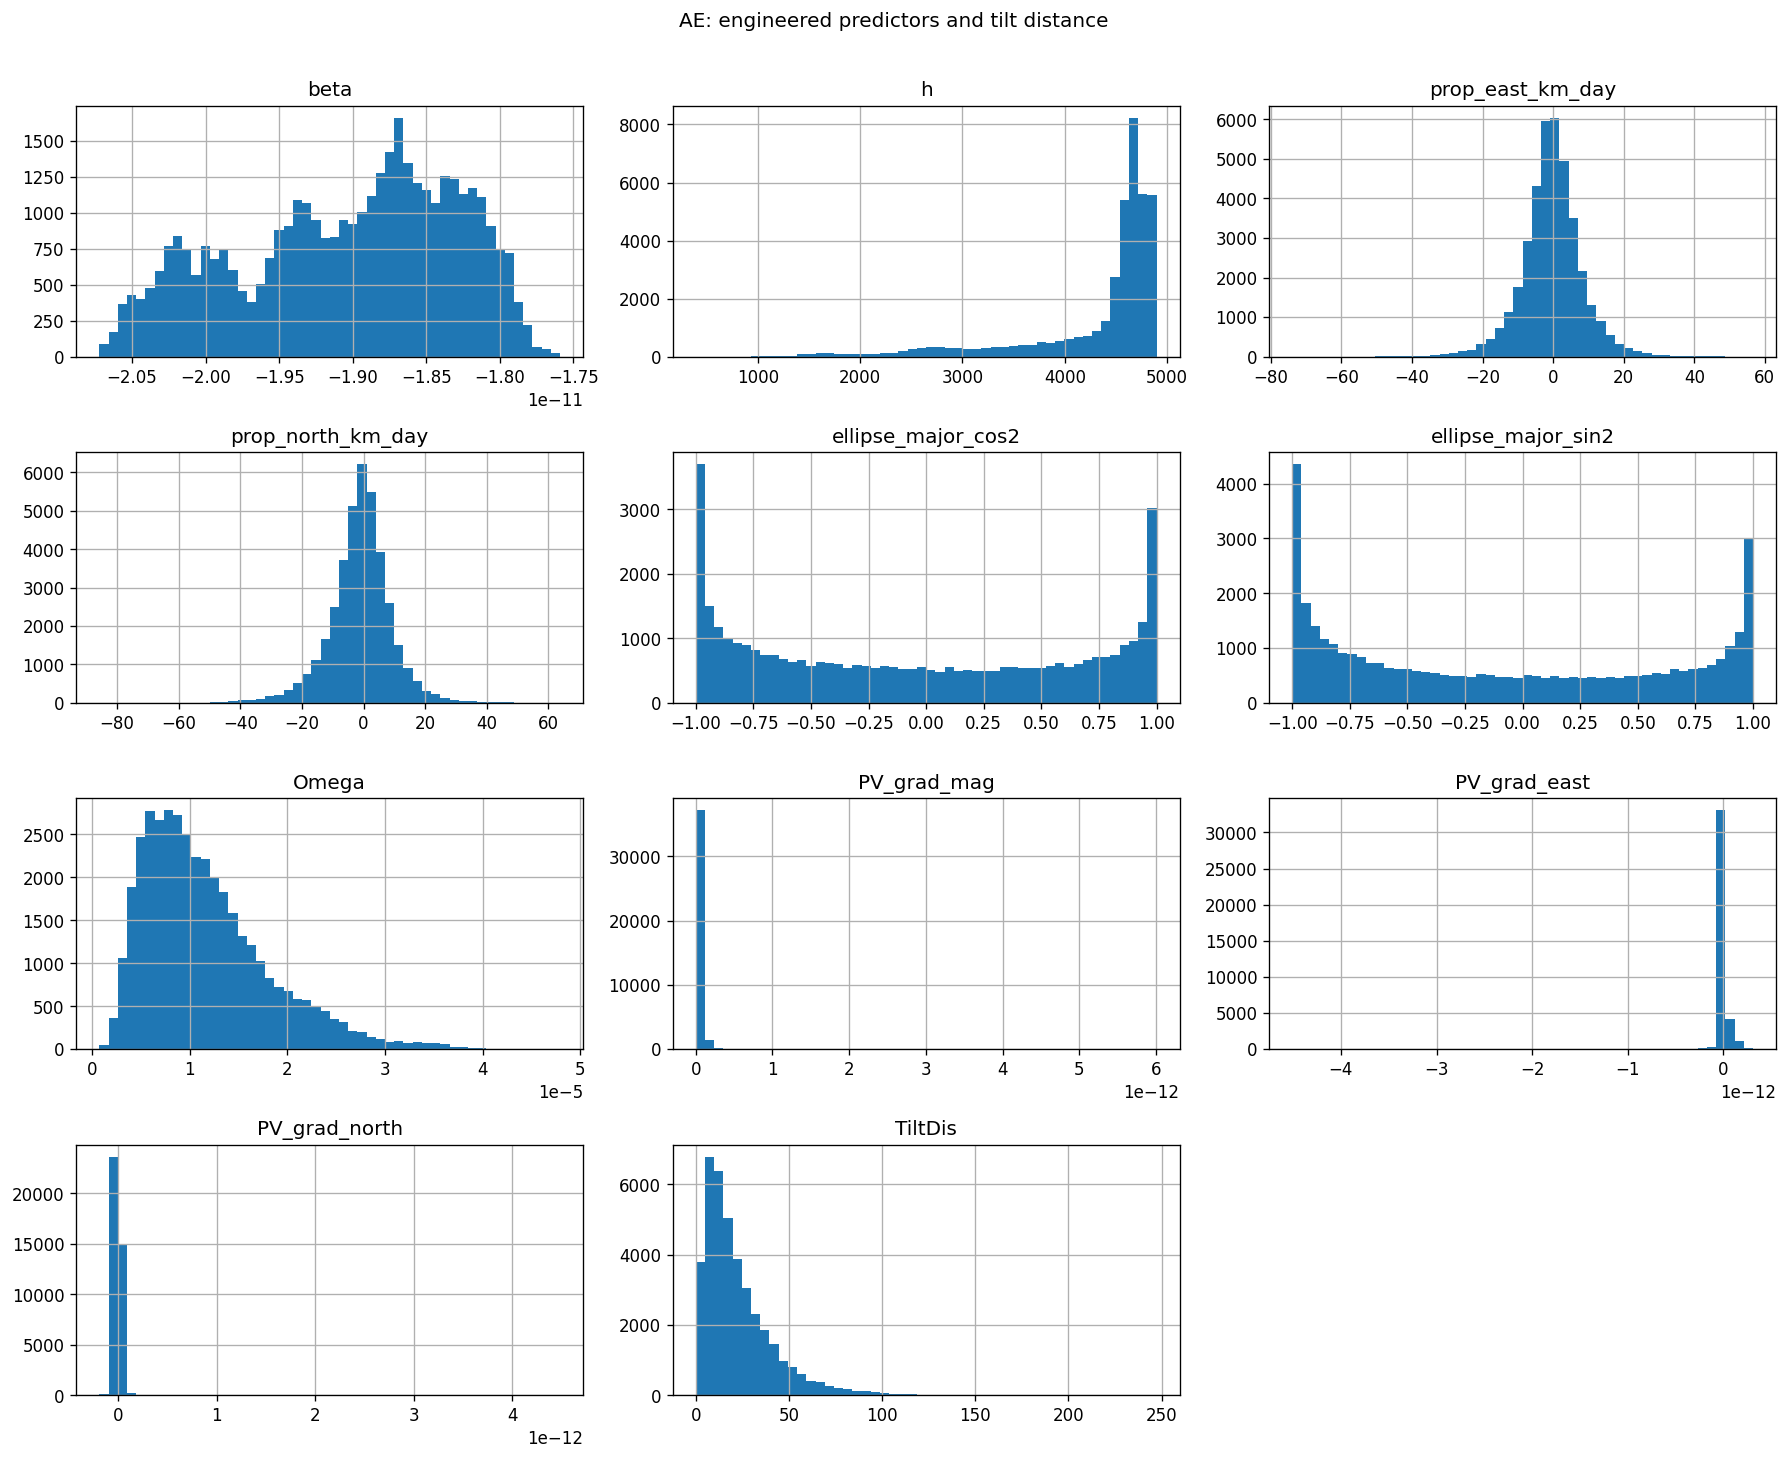

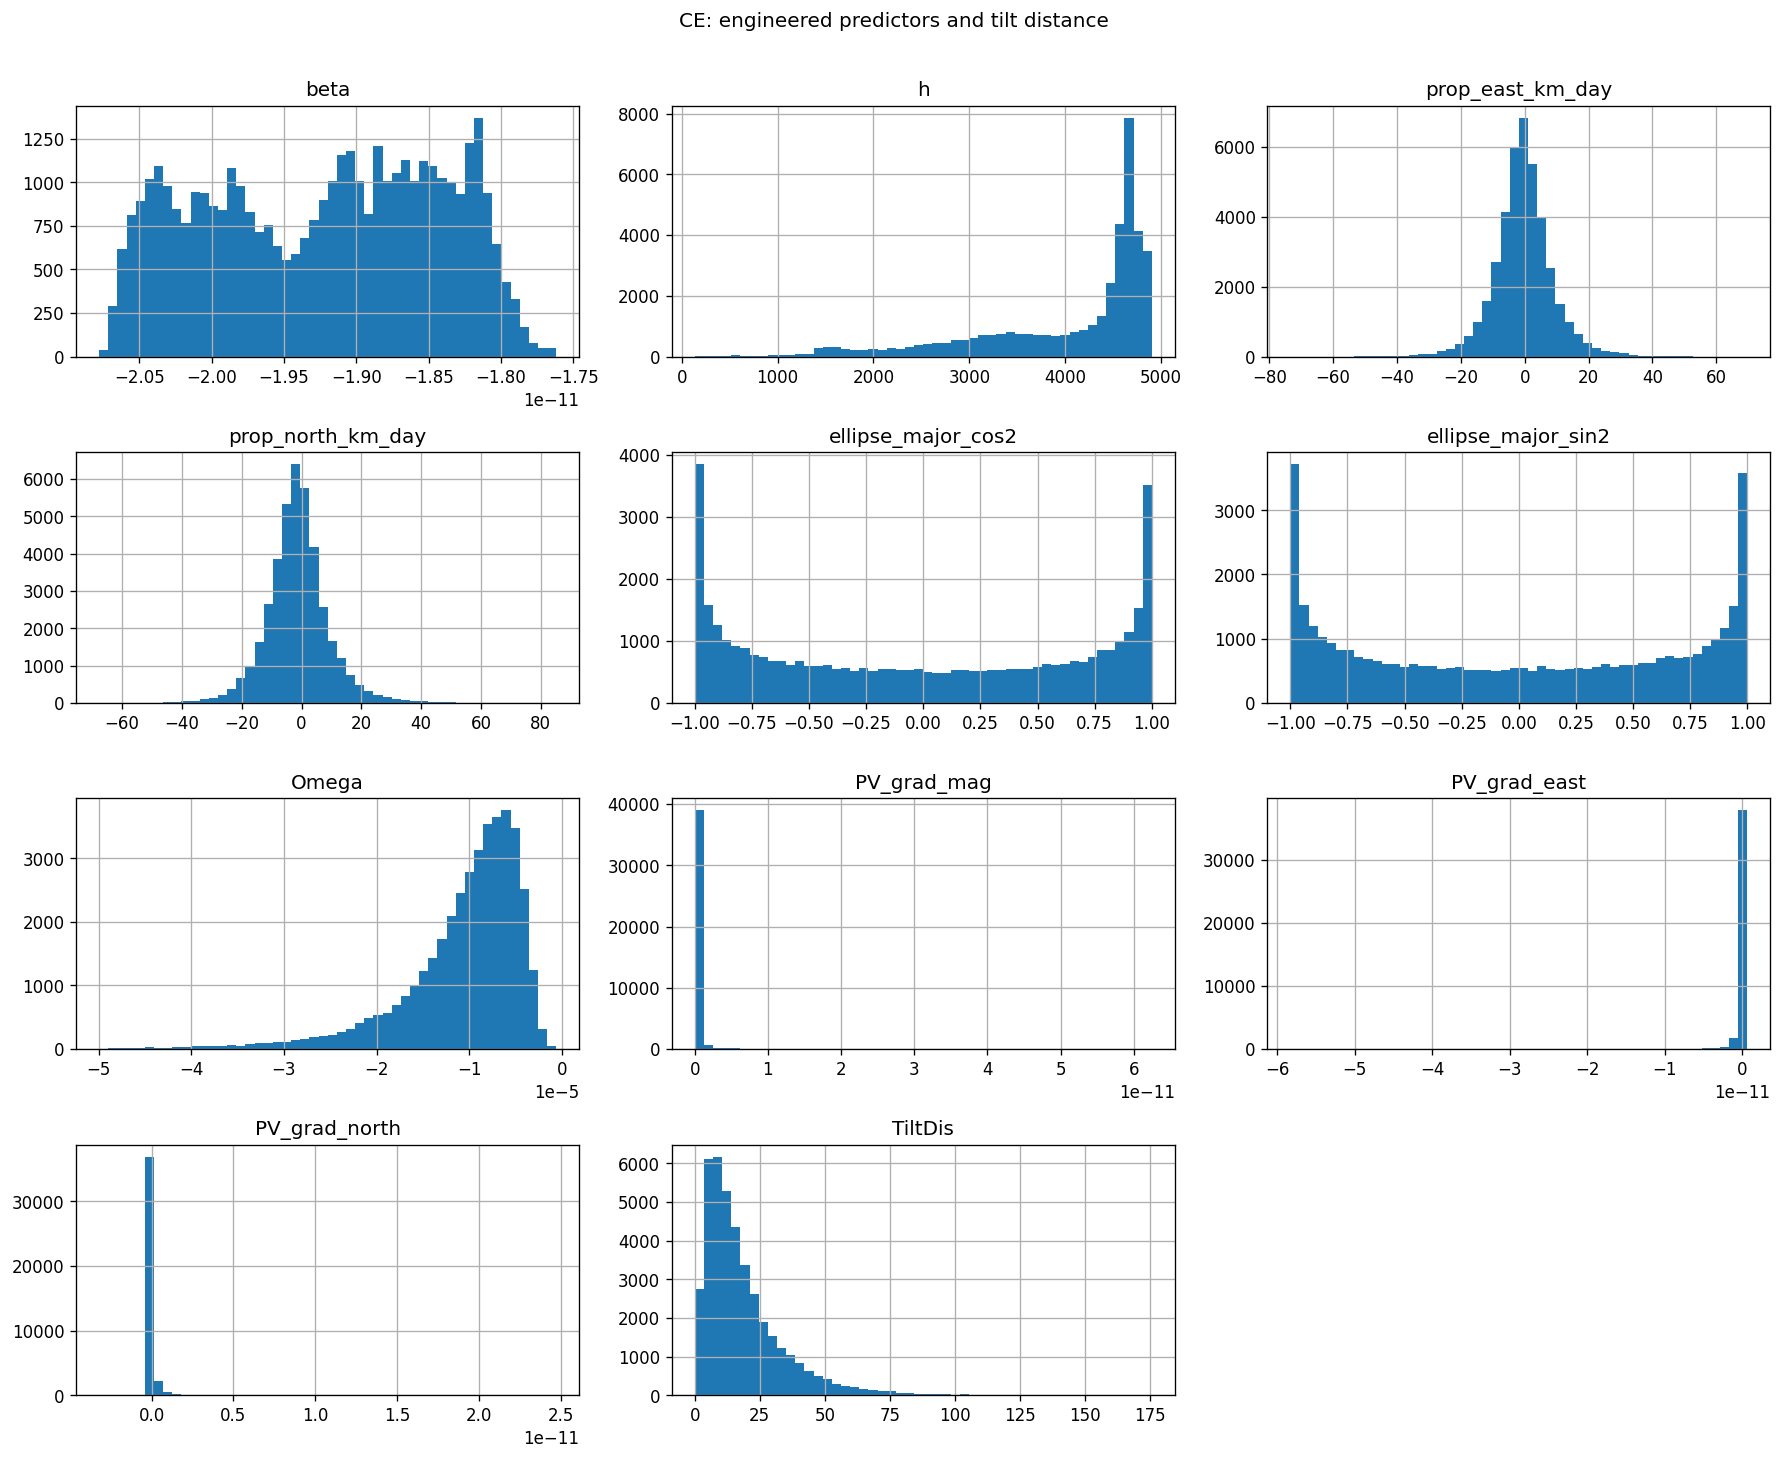

In [4]:
for cyc, part in polarity_data.items():
    part[ml.FEATURES + ["TiltDis"]].hist(bins=50, figsize=(15, 12))
    plt.suptitle(f"{cyc}: engineered predictors and tilt distance", y=1.01)
    plt.tight_layout()

### Direct test of the polarity-specific PV hypothesis

Before fitting any model, compare tilt direction with both the raw PV-gradient bearing and the polarity-expected reference. For CE the expected reference equals the PV gradient; for AE it is rotated by 180°.

In [5]:
hypothesis_rows = []
for cyc, part in polarity_data.items():
    raw_error = ml.angular_error_deg(part["TiltDir"], part["PV_grad_theta"])
    aligned_error = ml.angular_error_deg(part["TiltDir"], part["PV_reference_theta"])
    hypothesis_rows.append({
        "Cyc": cyc,
        "median_error_to_raw_PV_deg": np.median(raw_error),
        "within_30deg_raw_PV": np.mean(raw_error <= 30),
        "median_error_to_expected_reference_deg": np.median(aligned_error),
        "within_30deg_expected_reference": np.mean(aligned_error <= 30),
    })
pd.DataFrame(hypothesis_rows).set_index("Cyc").round(3)

,median_error_to_raw_PV_deg,within_30deg_raw_PV,median_error_to_expected_reference_deg,within_30deg_expected_reference
Cyc,,,,
AE,95.604,0.141,84.396,0.179
CE,64.149,0.259,64.149,0.259


## 3. Reserve untouched final-test eddies

AE and CE are split independently. Every observation from an eddy stays on one side of the split. Nothing below the next model-selection section may use the final test observations until Part 7.

In [6]:
splits = {
    cyc: ml.grouped_train_test_split(part, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    for cyc, part in polarity_data.items()
}

summary = []
for cyc, split in splits.items():
    assert set(split.groups_train).isdisjoint(set(split.groups_test))
    summary.append({
        "Cyc": cyc, "training rows": len(split.train), "test rows": len(split.test),
        "training eddies": split.groups_train.nunique(),
        "untouched test eddies": split.groups_test.nunique(),
    })
pd.DataFrame(summary).set_index("Cyc")

,training rows,test rows,training eddies,untouched test eddies
Cyc,,,,
AE,31407,7528,1027,257
CE,31964,8491,1168,293


## 4. Training-only grouped model and hyperparameter selection

Five-fold grouped CV compares Ridge regularisation, four restrained gradient-boosting configurations, and both target formulations. The PV-relative target is calculated relative to `PV_grad_theta` for CE and `PV_grad_theta + 180°` for AE. Each fold includes a mean-vector and polarity-aligned PV baseline. Selection uses equal-eddy-weighted vector MAE. This is the most computationally intensive section.

In [7]:
candidates = ml.default_candidates()
tuning = {}
selected = {}

for cyc, split in splits.items():
    print(f"Tuning {cyc}...")
    tuning[cyc] = ml.tune_candidates_grouped(
        split.train, candidates=candidates, n_splits=INNER_FOLDS, random_state=RANDOM_STATE
    )
    selected[cyc] = ml.best_candidate(tuning[cyc], candidates)
    print(cyc, selected[cyc])
    display(ml.summarise_tuning(tuning[cyc]).head(12).round(3))

Tuning AE...
AE {'family': 'Ridge', 'target_mode': 'cartesian', 'params': {'alpha': 100.0}}


,,,,vector_MAE_mean,vector_MAE_std,eddy_vector_MAE_mean,distance_MAE_mean,angular_error_median,within_30deg_mean
candidate_id,family,target_mode,params,,,,,,
3,Ridge,cartesian,{'alpha': 100.0},20.541,1.180,26.594,13.862,47.793,0.350
2,Ridge,cartesian,{'alpha': 10.0},20.546,1.181,26.598,13.857,47.809,0.350
1,Ridge,cartesian,{'alpha': 1.0},20.546,1.181,26.599,13.856,47.819,0.350
0,Ridge,cartesian,{'alpha': 0.1},20.546,1.181,26.599,13.856,47.822,0.350
8,Gradient boosting,cartesian,"{'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",20.568,1.336,26.677,13.460,45.164,0.360
10,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}",20.815,1.508,26.879,13.413,45.573,0.361
11,Gradient boosting,cartesian,"{'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 1.0}",20.902,1.321,26.975,13.384,45.870,0.357
9,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",21.032,1.358,27.242,13.409,45.524,0.358
Mean-vector baseline,Mean-vector baseline,baseline,{},21.583,1.123,27.731,15.316,54.037,0.285


Tuning CE...
CE {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}}


,,,,vector_MAE_mean,vector_MAE_std,eddy_vector_MAE_mean,distance_MAE_mean,angular_error_median,within_30deg_mean
candidate_id,family,target_mode,params,,,,,,
8,Gradient boosting,cartesian,"{'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",16.888,0.643,20.613,11.550,49.521,0.340
10,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}",16.986,0.622,20.683,11.233,48.702,0.342
9,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",17.172,0.690,20.862,11.196,49.637,0.341
11,Gradient boosting,cartesian,"{'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 1.0}",17.178,0.577,20.874,11.160,49.444,0.339
2,Ridge,cartesian,{'alpha': 10.0},17.331,0.727,20.966,12.382,53.082,0.320
1,Ridge,cartesian,{'alpha': 1.0},17.331,0.727,20.967,12.381,53.039,0.320
0,Ridge,cartesian,{'alpha': 0.1},17.331,0.727,20.967,12.381,53.040,0.320
3,Ridge,cartesian,{'alpha': 100.0},17.331,0.727,20.967,12.393,53.162,0.320
Mean-vector baseline,Mean-vector baseline,baseline,{},18.003,0.807,21.749,14.066,63.627,0.271


## 5. Training-only feature ablation

Using each polarity's selected model configuration, grouped CV tests PV magnitude, PV components, the full PV vector, and the retained propagation/ellipse dynamics. `AR` and the two weak tendency variables have already been removed based on the preceding untouched-test results. The final test set remains untouched.

AE selected feature set: full_PV_vector


,eddy_vector_MAE,fold_SD,distance_MAE,angular_error
feature_set,,,,
full_PV_vector,26.594,1.533,13.862,47.793
PV_components_only,26.618,1.501,13.845,47.996
PV_magnitude_only,26.630,1.520,13.860,48.137
surface_without_PV,26.682,1.491,13.870,48.269
full_without_dynamics,27.124,1.497,14.925,55.389


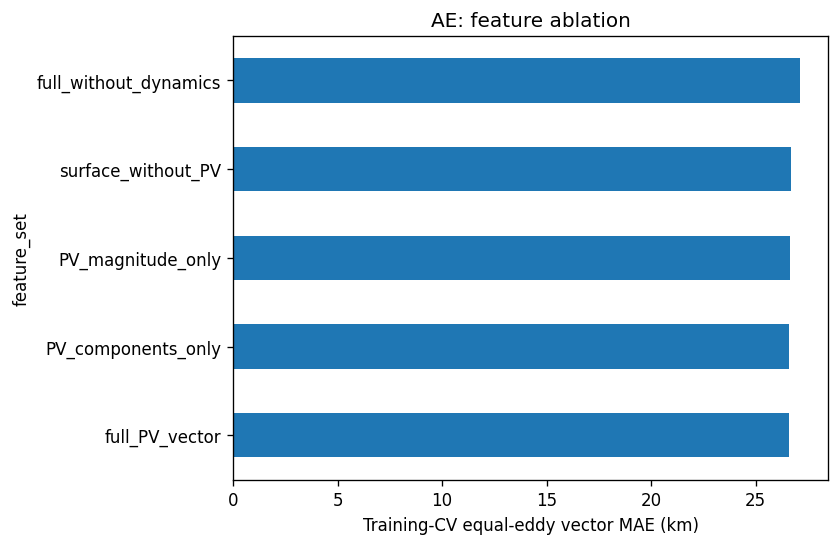

CE selected feature set: full_PV_vector


,eddy_vector_MAE,fold_SD,distance_MAE,angular_error
feature_set,,,,
full_PV_vector,20.613,1.057,11.550,49.521
PV_components_only,20.653,1.139,11.448,49.277
PV_magnitude_only,20.733,1.087,11.773,51.026
surface_without_PV,20.858,1.149,11.924,52.836
full_without_dynamics,21.470,1.065,11.978,57.751


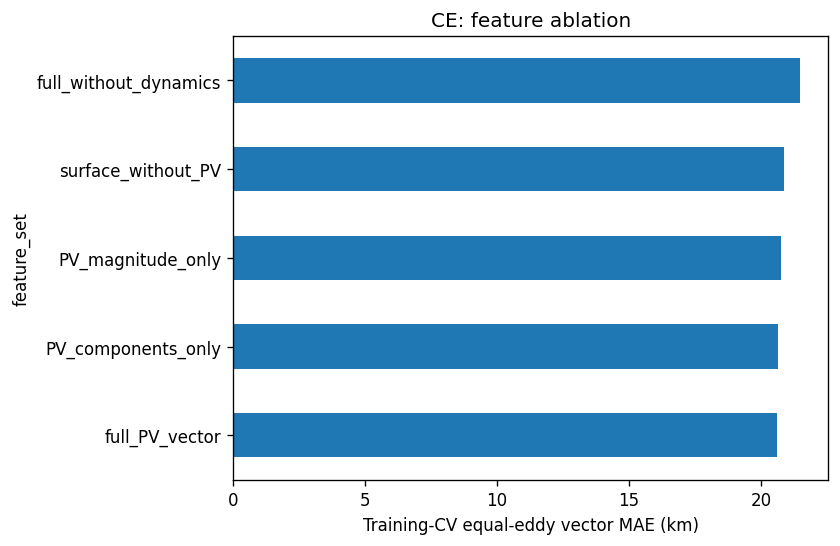

In [8]:
ablation = {}
chosen_features = {}
for cyc, split in splits.items():
    ablation[cyc] = ml.feature_ablation_cv(
        split.train, selected[cyc], n_splits=INNER_FOLDS, random_state=RANDOM_STATE
    )
    ablation_summary = (
        ablation[cyc].groupby("feature_set")
        .agg(eddy_vector_MAE=("eddy_weighted_vector_MAE_km", "mean"),
             fold_SD=("eddy_weighted_vector_MAE_km", "std"),
             distance_MAE=("distance_MAE_km", "mean"),
             angular_error=("median_angular_error_deg", "median"))
        .sort_values("eddy_vector_MAE")
    )
    best_set = ablation_summary.index[0]
    chosen_features[cyc] = ml.FEATURE_SETS[best_set]
    print(f"{cyc} selected feature set: {best_set}")
    display(ablation_summary.round(3))
    ablation_summary["eddy_vector_MAE"].sort_values().plot.barh(title=f"{cyc}: feature ablation")
    plt.xlabel("Training-CV equal-eddy vector MAE (km)")
    plt.show()

## 6. Repeated grouped validation inside the training population

Five additional grouped holdouts test sensitivity to which training eddies are selected. Baselines are recomputed inside every repeat. These repeats use only the original training population.

In [9]:
repeated = {}
for cyc, split in splits.items():
    repeated[cyc] = ml.repeated_grouped_validation(
        split.train, selected[cyc], features=chosen_features[cyc],
        n_repeats=REPEATED_SPLITS, random_state=100,
    )
    display(repeated[cyc].groupby("model").agg(
        vector_MAE=("eddy_weighted_vector_MAE_km", "mean"),
        split_SD=("eddy_weighted_vector_MAE_km", "std"),
        distance_MAE=("eddy_weighted_distance_MAE_km", "mean"),
        angular_error=("median_angular_error_deg", "median"),
    ).sort_values("vector_MAE").round(3))

,vector_MAE,split_SD,distance_MAE,angular_error
model,,,,
Selected model,26.649,0.930,18.778,48.649
Mean-vector baseline,27.947,1.296,20.832,57.169
Polarity-aligned PV baseline,36.148,1.267,16.552,83.892


,vector_MAE,split_SD,distance_MAE,angular_error
model,,,,
Selected model,20.512,0.552,13.897,50.285
Mean-vector baseline,21.248,0.535,16.816,62.988
Polarity-aligned PV baseline,24.801,0.398,12.769,63.817


## 7. One final evaluation on untouched eddies

All model and feature choices are now fixed. Each selected model is fitted to all training eddies and evaluated once against its untouched final-test eddies. Both row-weighted and equal-eddy-weighted errors are reported.

AE: {'family': 'Ridge', 'target_mode': 'cartesian', 'params': {'alpha': 100.0}}
Features: ['beta', 'h', 'prop_east_km_day', 'prop_north_km_day', 'ellipse_major_cos2', 'ellipse_major_sin2', 'Omega', 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']


,vector_MAE_km,vector_RMSE_km,distance_MAE_km,distance_RMSE_km,east_R2,north_R2,median_angular_error_deg,within_30deg_fraction,eddy_weighted_vector_MAE_km,eddy_weighted_distance_MAE_km
model,,,,,,,,,,
Selected model,21.784,28.334,14.967,22.587,0.080,0.084,47.740,0.348,28.517,20.647
Mean-vector baseline,22.751,29.587,16.313,24.644,-0.001,-0.000,58.477,0.279,29.478,22.458
Polarity-aligned PV baseline,31.775,37.449,13.663,19.687,-0.729,-0.485,85.117,0.172,37.941,17.765


CE: {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}}
Features: ['beta', 'h', 'prop_east_km_day', 'prop_north_km_day', 'ellipse_major_cos2', 'ellipse_major_sin2', 'Omega', 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']


,vector_MAE_km,vector_RMSE_km,distance_MAE_km,distance_RMSE_km,east_R2,north_R2,median_angular_error_deg,within_30deg_fraction,eddy_weighted_vector_MAE_km,eddy_weighted_distance_MAE_km
model,,,,,,,,,,
Selected model,17.134,22.540,11.685,17.753,0.153,0.105,44.693,0.365,20.301,14.08
Mean-vector baseline,18.499,24.211,14.838,21.565,-0.001,-0.011,56.004,0.313,21.579,17.53
Polarity-aligned PV baseline,22.524,27.082,10.917,16.309,-0.304,-0.216,67.507,0.243,25.002,12.94


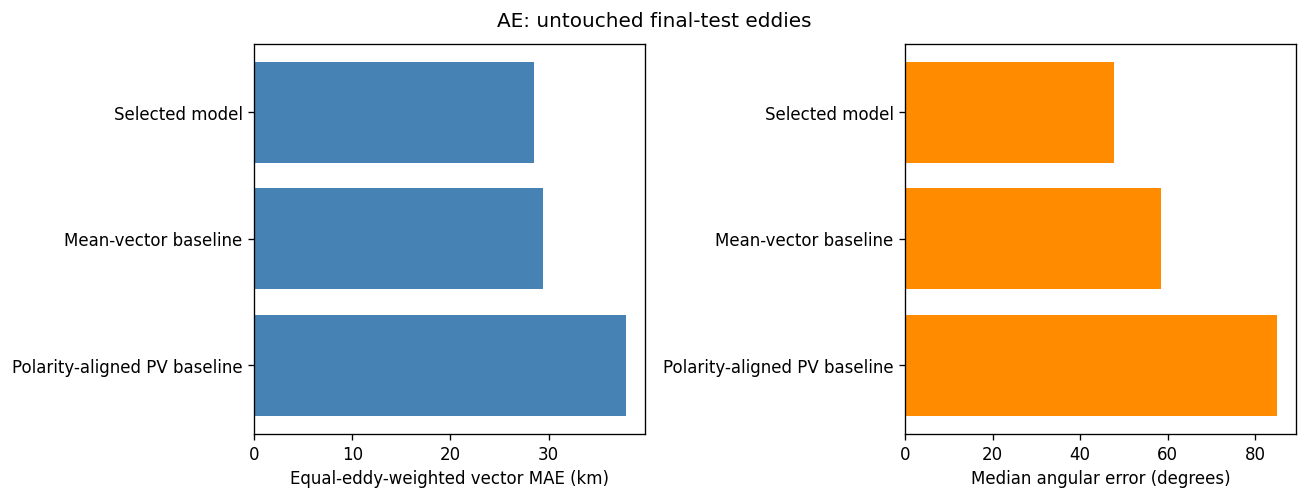

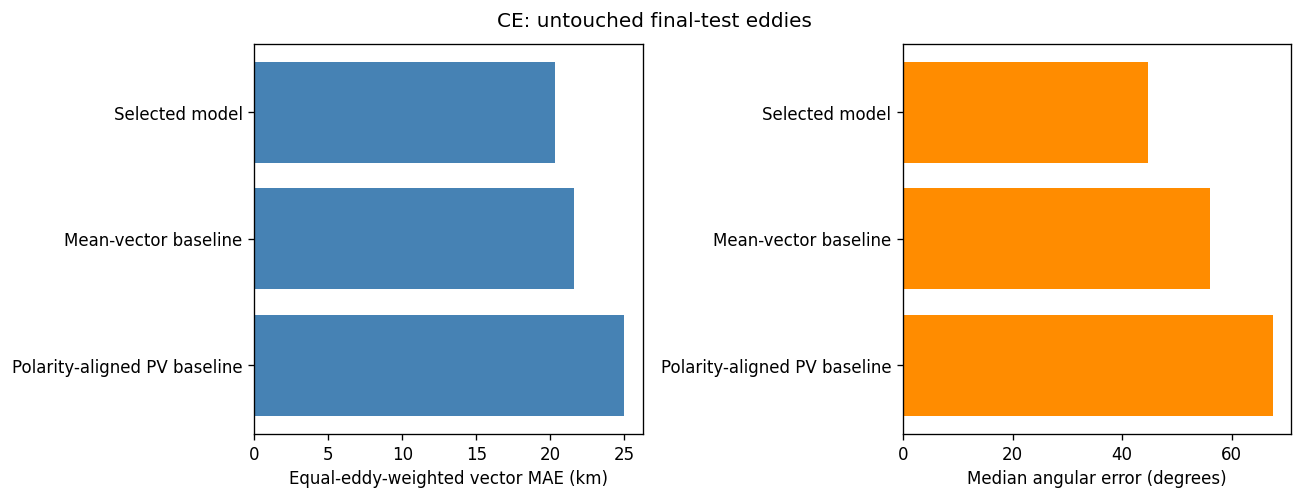

In [10]:
final_results = {}
for cyc, split in splits.items():
    fitted, prediction, scores, predictions = ml.fit_selected_and_test(
        selected[cyc], split, features=chosen_features[cyc], random_state=RANDOM_STATE
    )
    final_results[cyc] = {
        "fitted": fitted, "prediction": prediction,
        "scores": scores, "predictions": predictions,
    }
    print(f"{cyc}: {selected[cyc]}")
    print(f"Features: {chosen_features[cyc]}")
    display(scores.round(3))
    fig, axes = ml.plot_model_comparison(scores)
    fig.suptitle(f"{cyc}: untouched final-test eddies", y=1.03)

,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
0,7528,47.740,0.348
5,6857,45.386,0.361
10,5700,43.013,0.379
20,3460,38.640,0.407


,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
0,8491,44.693,0.365
5,7565,42.719,0.380
10,5824,39.832,0.402
20,2954,37.224,0.423


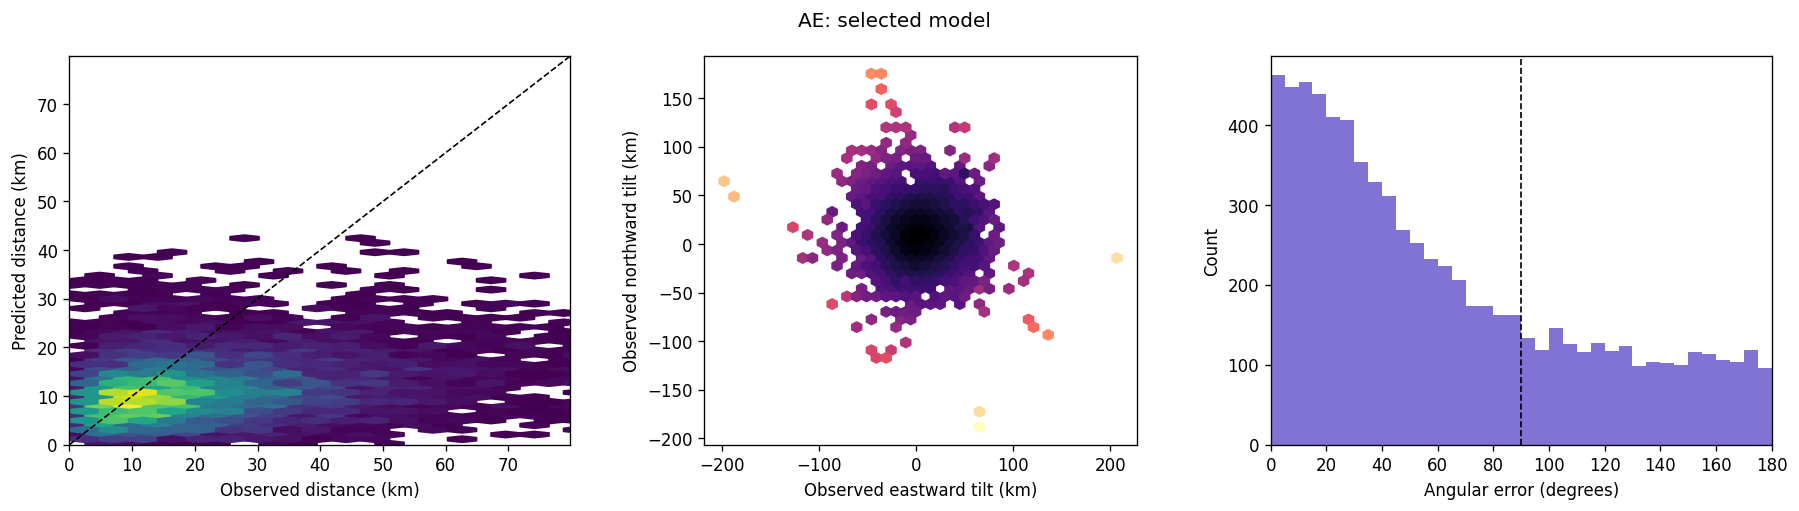

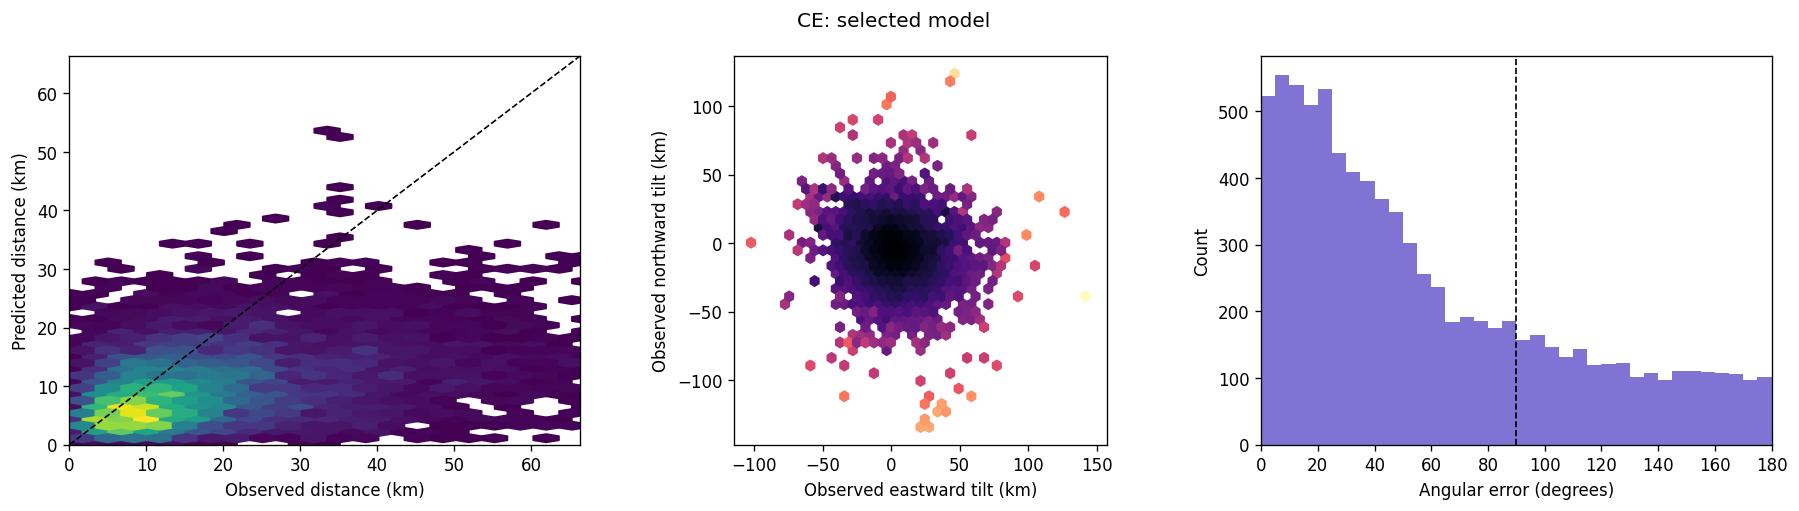

In [11]:
for cyc, result in final_results.items():
    ml.plot_prediction_diagnostics(result["prediction"], title=f"{cyc}: selected model")
    display(ml.direction_performance_by_tilt(
        result["prediction"], thresholds=(0, 5, 10, 20)
    ).round(3))

## 8. Final-test permutation importance

Importance measures the increase in equal-eddy-weighted vector MAE after shuffling one selected feature in the untouched test set. It measures predictive reliance, not causality.

,feature,importance_mean,importance_std
7,PV_grad_mag,0.6742,0.0204
3,prop_north_km_day,0.4696,0.0599
0,beta,0.4651,0.0713
2,prop_east_km_day,0.4302,0.0589
5,ellipse_major_sin2,0.2826,0.0579
4,ellipse_major_cos2,0.2608,0.0228
6,Omega,0.0199,0.0098
1,h,0.0045,0.0052
8,PV_grad_east,-0.0114,0.0288
9,PV_grad_north,-0.0890,0.0069


,feature,importance_mean,importance_std
0,beta,1.1127,0.0347
2,prop_east_km_day,0.7713,0.0376
8,PV_grad_east,0.7687,0.0514
3,prop_north_km_day,0.7079,0.0460
9,PV_grad_north,0.5143,0.0469
1,h,0.4685,0.0180
7,PV_grad_mag,0.3846,0.0356
6,Omega,0.2720,0.0387
5,ellipse_major_sin2,0.1879,0.0523
4,ellipse_major_cos2,0.0386,0.0169


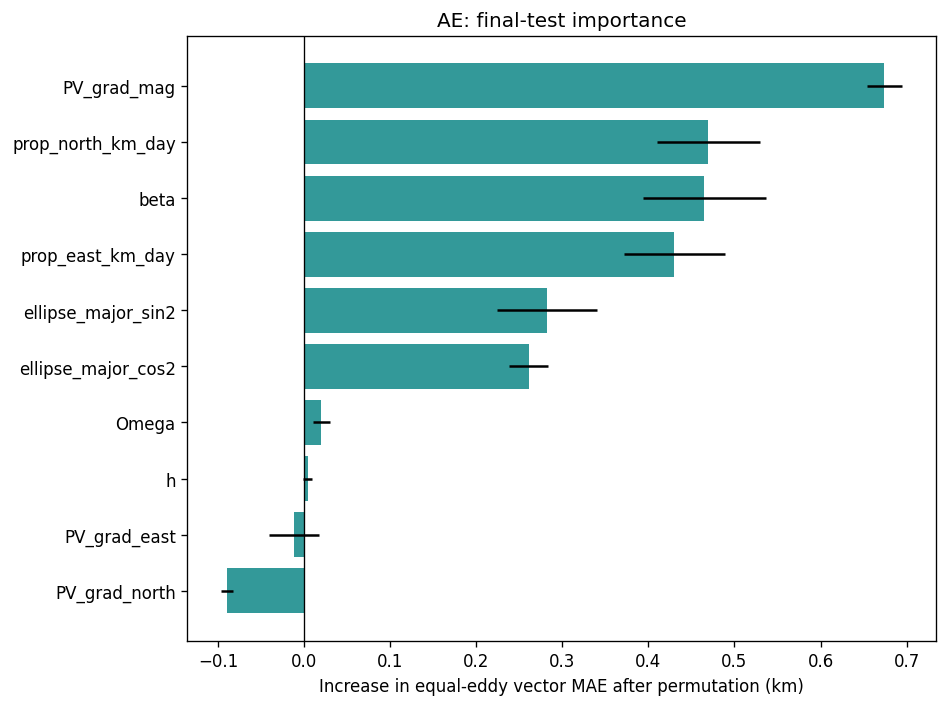

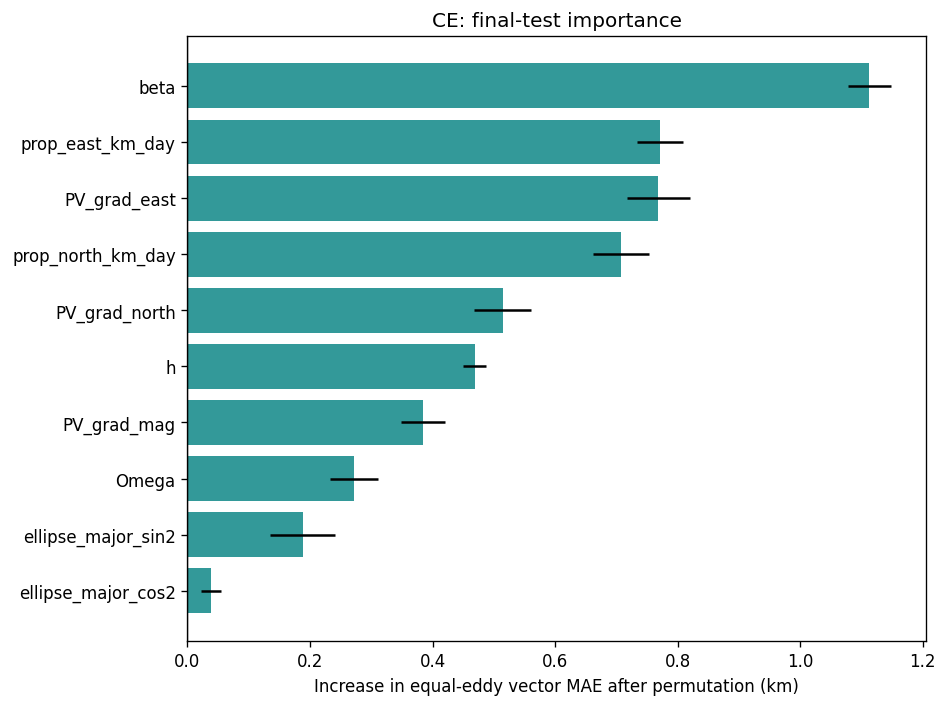

In [12]:
importance_results = {}
for cyc, result in final_results.items():
    importance = ml.raw_feature_permutation_importance(
        result["fitted"], splits[cyc].test, selected[cyc],
        features=chosen_features[cyc], n_repeats=10, random_state=RANDOM_STATE,
    )
    importance_results[cyc] = importance
    display(importance.round(4))
    ml.plot_permutation_importance(importance, title=f"{cyc}: final-test importance")

## 9. Interpretation checklist

A polarity-specific ML approach is supported only if the selected model improves consistently over both fold-specific baselines during tuning, repeated training-only validation, and the untouched final test. Prioritise equal-eddy-weighted vector MAE; then inspect distance and thresholded angular skill.

Report for AE and CE separately:

- the selected model family, hyperparameters, target formulation, and feature set;
- training-CV and repeated-split performance relative to both baselines;
- untouched test performance, including equal-eddy-weighted metrics;
- whether the polarity-aware PV-relative target improves direction;
- whether PV magnitude adds information beyond its components;
- whether propagation and ellipse orientation improve CV;
- performance for larger tilts, where direction is better defined.

Do not interpret permutation importance as causal evidence. A negative result remains scientifically useful: it indicates that the tested surface signatures do not constrain instantaneous 859 m tilt sufficiently for unseen eddies.